# Adaptive Round-Up Prediction for Micro-Savings(Jomao)
### ML Framework for Behavior-Aware Round-Up Prediction | bKash · Nagad · Rocket

---

## Research Context

Bangladesh's MFS ecosystem processes hundreds of millions of transactions annually, yet no intelligent mechanism exists for converting everyday payments into automatic savings. This notebook builds a supervised regression model that predicts a **personalized, behavior-aware round-up amount** for each Make Payment transaction in real time.

$$\text{Round-Up Amount (Tk)} = f(\text{Transaction Amount, User Behavior, Financial State, Historical Patterns})$$



## Problem Statement  
Fixed round-up systems ignore user-specific behavioral and financial patterns.

There is no data-driven framework to answer:

> Given a user’s transaction amount, historical behavior, and financial state — what is the optimal round-up amount for this payment?



## Solution
A ml regression model that learns the interaction between transaction amount, income tier, intraday pressure signals, and historical spending patterns to predict an adaptive round-up that is both meaningful and fair.



## Research Significance  

This dataset enables:

- Personalized micro-savings prediction  
- Behavior-aware financial modeling  
- Real-time adaptive rounding systems  

It demonstrates that **round-up amounts can be learned from user behavior rather than fixed rules**, making micro-savings more efficient and user-friendly.


## Dataset
Synthetically generated structured transactional dataset designed for machine learning-based micro-savings prediction

---

## 1. Import Data and Required Packages

In [28]:
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

from pathlib import Path

In [ ]:
# setup configuration
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style="darkgrid")
plt.rcParams.update({
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8
})


RANDOM_STATE = 42

DATA_PATH = Path(
    r"E:\ml projects\end-to-end-roundup-prediction\notebooks\roundup_data.csv"
)

In [11]:
df = pd.read_csv(DATA_PATH)

In [13]:
df.head(10)

,txn_id,user_id,timestamp,txn_amount,category,transaction_hour,is_weekend,hour_sin,hour_cos,txn_count_today,daily_total_spent,remaining_daily_capacity,txn_count_prev_7d,avg_spend_last_7days,spending_velocity_ratio,income_tier,user_tenure_days,is_new_user,pressure_score,monthly_savings_so_far,user_savings_streak,days_since_last_txn,clean_number_tier,rounded_amount,roundup_amount
0,TXN_00000001,USR_0001,2024-09-02 09:39:46,464,food_delivery,9,0,0.707,-0.707,1,0.000,600.000,0,450.000,1.031,Low,229,0,0.029,0,0,0,3,500,36
1,TXN_00000002,USR_0001,2024-09-02 13:53:43,460,ride_sharing,13,0,-0.259,-0.966,2,464.000,136.000,0,450.000,1.022,Low,229,0,0.888,36,0,0,3,500,40
2,TXN_00000003,USR_0001,2024-09-02 18:12:46,130,ride_sharing,18,0,-1.000,-0.000,3,924.000,-324.000,0,450.000,0.289,Low,229,0,0.950,76,0,0,3,150,20
3,TXN_00000004,USR_0001,2024-09-14 08:48:51,360,shopping,8,1,0.866,-0.500,1,0.000,600.000,0,450.000,0.800,Low,241,0,0.009,96,0,12,3,400,40
4,TXN_00000005,USR_0001,2024-09-14 13:16:36,692,ride_sharing,13,1,-0.259,-0.966,2,360.000,240.000,0,450.000,1.538,Low,241,0,0.710,136,0,0,3,750,58
5,TXN_00000006,USR_0001,2024-09-14 18:42:01,671,ride_sharing,18,1,-1.000,-0.000,3,1052.000,-452.000,0,450.000,1.491,Low,241,0,0.950,194,0,0,3,700,29
6,TXN_00000007,USR_0001,2024-09-14 18:56:02,608,ride_sharing,18,1,-1.000,-0.000,4,1723.000,-1123.000,0,450.000,1.351,Low,241,0,0.950,223,0,0,3,650,42
7,TXN_00000008,USR_0001,2024-09-17 06:11:29,694,shopping,6,0,1.000,0.000,1,0.000,600.000,4,582.750,1.191,Low,244,0,0.017,265,0,3,3,750,56
8,TXN_00000009,USR_0001,2024-09-17 18:11:42,110,ride_sharing,18,0,-1.000,-0.000,2,694.000,-94.000,4,582.750,0.189,Low,244,0,0.950,321,0,0,3,150,40
9,TXN_00000010,USR_0001,2024-09-19 07:33:26,575,ecommerce,7,0,0.966,-0.259,1,0.000,600.000,6,522.500,1.101,Low,246,0,0.022,361,0,2,3,600,25


In [14]:
print("DataFrame Shape: ", df.shape)

DataFrame Shape:  (24222, 25)


## 2. Exploratory Data Analysis (EDA)

In [15]:
# basic data overview
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24222 entries, 0 to 24221
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   txn_id                    24222 non-null  str    
 1   user_id                   24222 non-null  str    
 2   timestamp                 24222 non-null  str    
 3   txn_amount                24222 non-null  int64  
 4   category                  24222 non-null  str    
 5   transaction_hour          24222 non-null  int64  
 6   is_weekend                24222 non-null  int64  
 7   hour_sin                  24222 non-null  float64
 8   hour_cos                  24222 non-null  float64
 9   txn_count_today           24222 non-null  int64  
 10  daily_total_spent         24222 non-null  float64
 11  remaining_daily_capacity  24222 non-null  float64
 12  txn_count_prev_7d         24222 non-null  int64  
 13  avg_spend_last_7days      24222 non-null  float64
 14  spending_velocity

In [16]:
TARGET_COL = "roundup_amount"
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Target column: ", TARGET_COL)
print("\nNumerical columns: ", num_cols)
print("\nCategorical columns: ", cat_cols)

Target column:  roundup_amount

Numerical columns:  ['txn_amount', 'transaction_hour', 'is_weekend', 'hour_sin', 'hour_cos', 'txn_count_today', 'daily_total_spent', 'remaining_daily_capacity', 'txn_count_prev_7d', 'avg_spend_last_7days', 'spending_velocity_ratio', 'user_tenure_days', 'is_new_user', 'pressure_score', 'monthly_savings_so_far', 'user_savings_streak', 'days_since_last_txn', 'clean_number_tier', 'rounded_amount', 'roundup_amount']

Categorical columns:  ['txn_id', 'user_id', 'timestamp', 'category', 'income_tier']


In [17]:
# missing value analyze
df.isnull().sum()

txn_id                      0
user_id                     0
timestamp                   0
txn_amount                  0
category                    0
transaction_hour            0
is_weekend                  0
hour_sin                    0
hour_cos                    0
txn_count_today             0
daily_total_spent           0
remaining_daily_capacity    0
txn_count_prev_7d           0
avg_spend_last_7days        0
spending_velocity_ratio     0
income_tier                 0
user_tenure_days            0
is_new_user                 0
pressure_score              0
monthly_savings_so_far      0
user_savings_streak         0
days_since_last_txn         0
clean_number_tier           0
rounded_amount              0
roundup_amount              0
dtype: int64

In [18]:
# check duplicates
df.duplicated().sum()

np.int64(0)

In [19]:
# descriptive stats for numerical columns
df[num_cols].describe()

,txn_amount,transaction_hour,is_weekend,hour_sin,hour_cos,txn_count_today,daily_total_spent,remaining_daily_capacity,txn_count_prev_7d,avg_spend_last_7days,spending_velocity_ratio,user_tenure_days,is_new_user,pressure_score,monthly_savings_so_far,user_savings_streak,days_since_last_txn,clean_number_tier,rounded_amount,roundup_amount
count,24222.000,24222.000,24222.000,24222.000,24222.000,24222.000,24222.000,24222.000,24222.000,24222.000,24222.000,24222.000,24222.000,24222.000,24222.000,24222.000,24222.000,24222.000,24222.000,24222.000
mean,1101.320,13.488,0.292,-0.180,-0.324,1.996,1091.268,1026.901,4.376,1100.524,1.080,182.186,0.036,0.483,764.334,0.829,1.456,2.635,1166.821,65.502
std,745.157,5.021,0.455,0.737,0.566,0.999,1404.625,1657.312,3.385,555.280,0.676,77.881,0.186,0.418,758.066,2.653,2.807,0.654,770.500,68.368
min,100.000,0.000,0.000,-1.000,-1.000,1.000,0.000,-4340.000,0.000,101.000,0.092,0.000,0.000,0.000,0.000,0.000,0.000,1.000,150.000,20.000
25%,492.000,9.000,0.000,-0.866,-0.866,1.000,0.000,-63.000,2.000,529.250,0.598,133.000,0.000,0.025,232.000,0.000,0.000,2.000,550.000,34.000
50%,879.000,14.000,0.000,-0.259,-0.500,2.000,555.000,600.000,4.000,1075.000,1.004,194.000,0.000,0.515,523.000,0.000,0.000,3.000,950.000,49.000
75%,1636.000,18.000,1.000,0.500,-0.000,3.000,1736.000,1500.000,7.000,1539.880,1.431,242.000,0.000,0.950,1010.000,0.000,2.000,3.000,1700.000,64.000
max,3000.000,23.000,1.000,1.000,1.000,4.000,8314.000,4000.000,20.000,2985.000,9.265,331.000,1.000,0.950,4686.000,16.000,32.000,3.000,3500.000,519.000


In [20]:
# descriptive stats for categorical columns
df[cat_cols].describe()

,txn_id,user_id,timestamp,category,income_tier
count,24222,24222,24222,24222,24222
unique,24222,420,24163,4,3
top,TXN_00000001,USR_0320,2024-10-07 18:17:54,food_delivery,Medium
freq,1,114,2,6089,8865


### Univariate Analysis

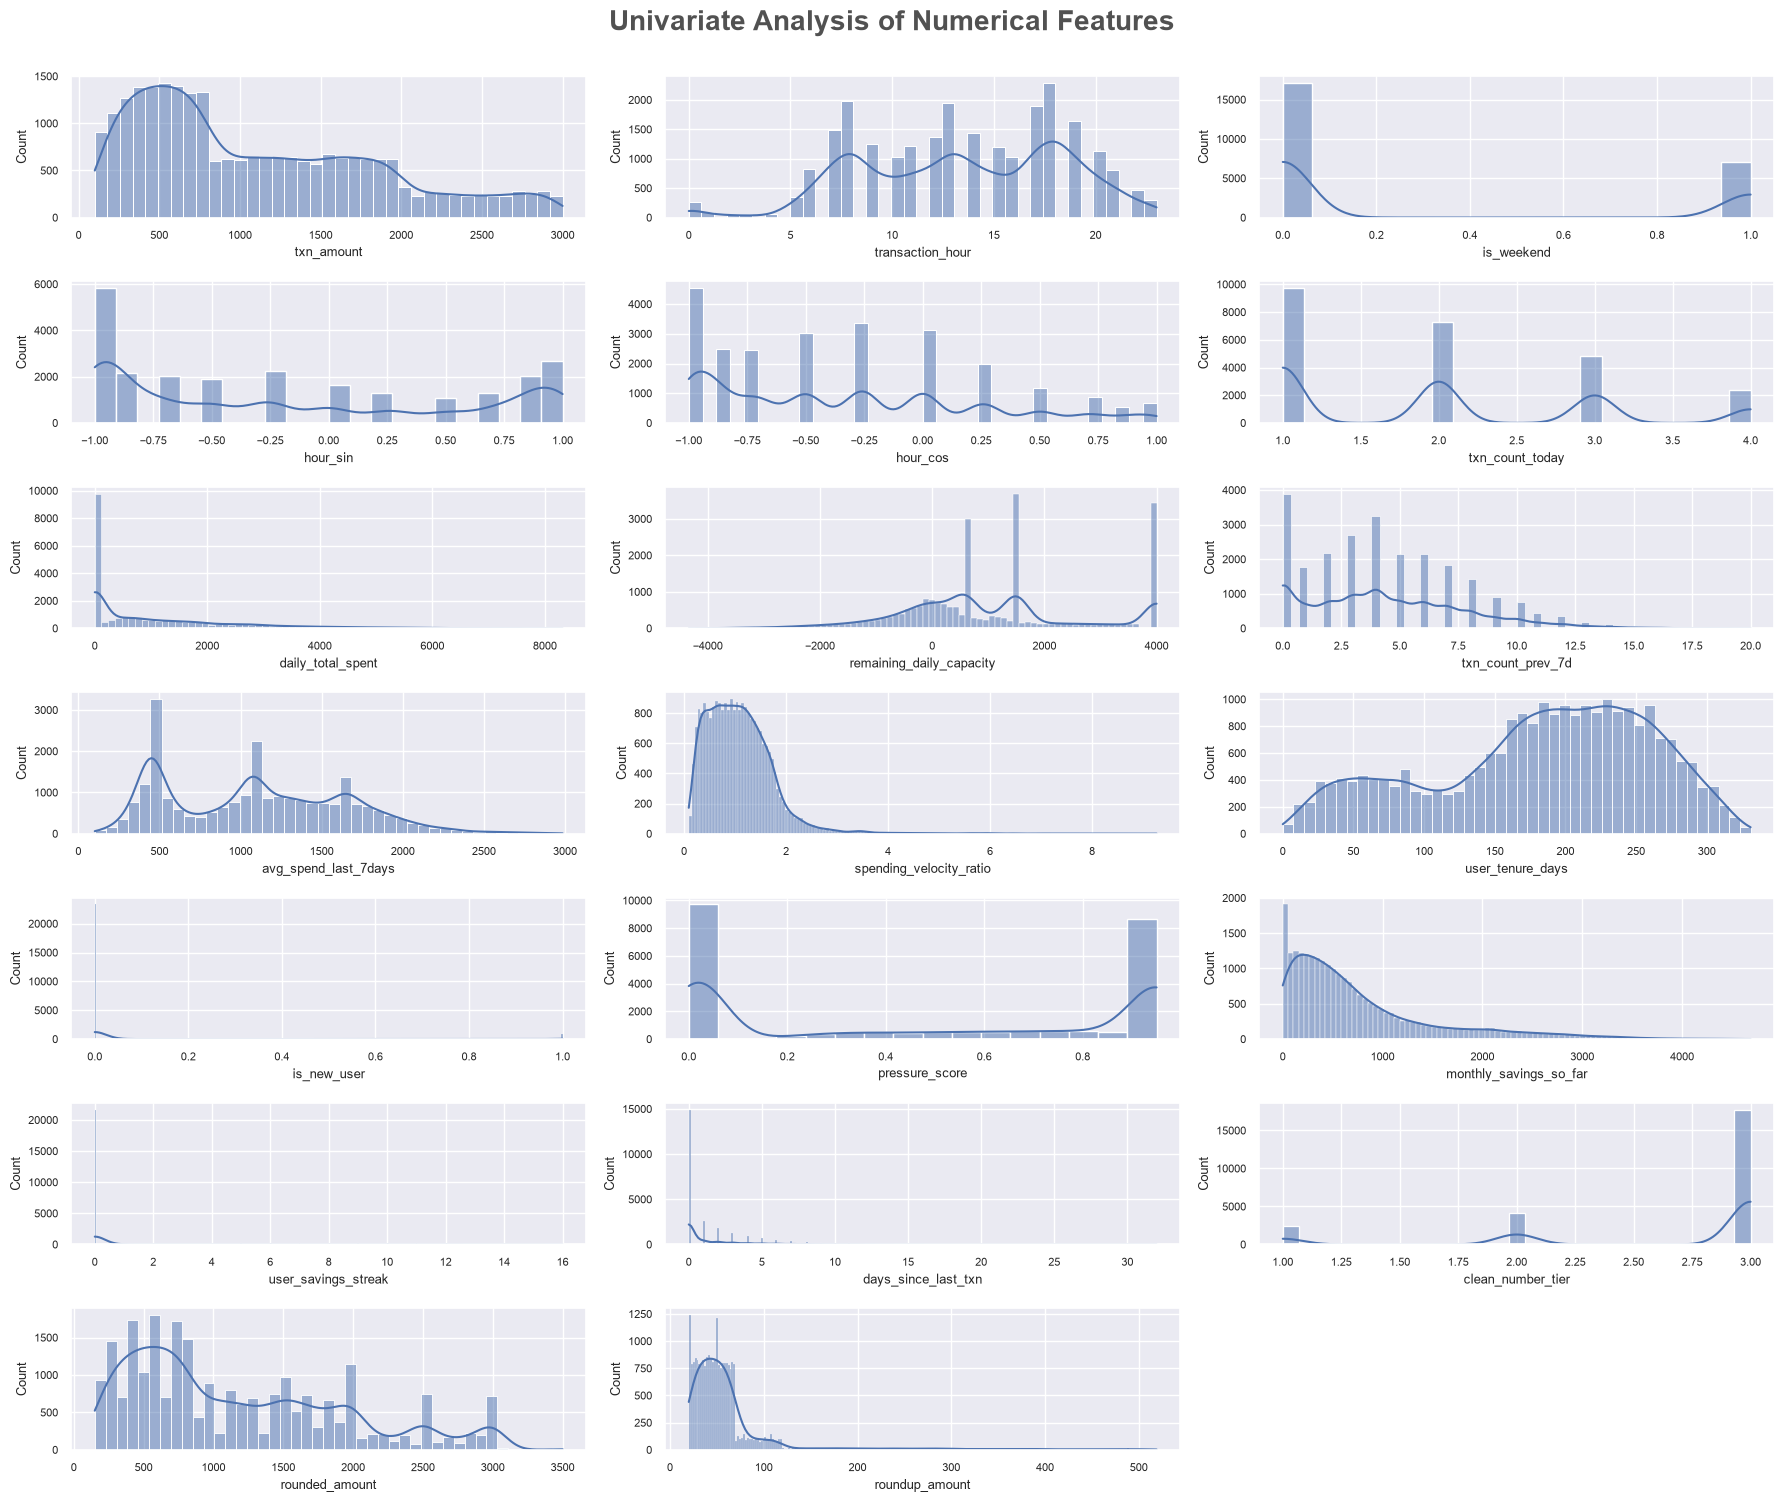

In [21]:
# Numerical Features
plt.figure(figsize=(18,15))
plt.suptitle('Univariate Analysis of Numerical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(num_cols)):
    plt.subplot(7, 3, i+1)
    sns.histplot(x=df[num_cols[i]], kde=True)
    plt.xlabel(num_cols[i])

plt.tight_layout()

# save plot
# plt.savefig('Univariate_Num.png', dpi=300, bbox_inches='tight')
plt.show()

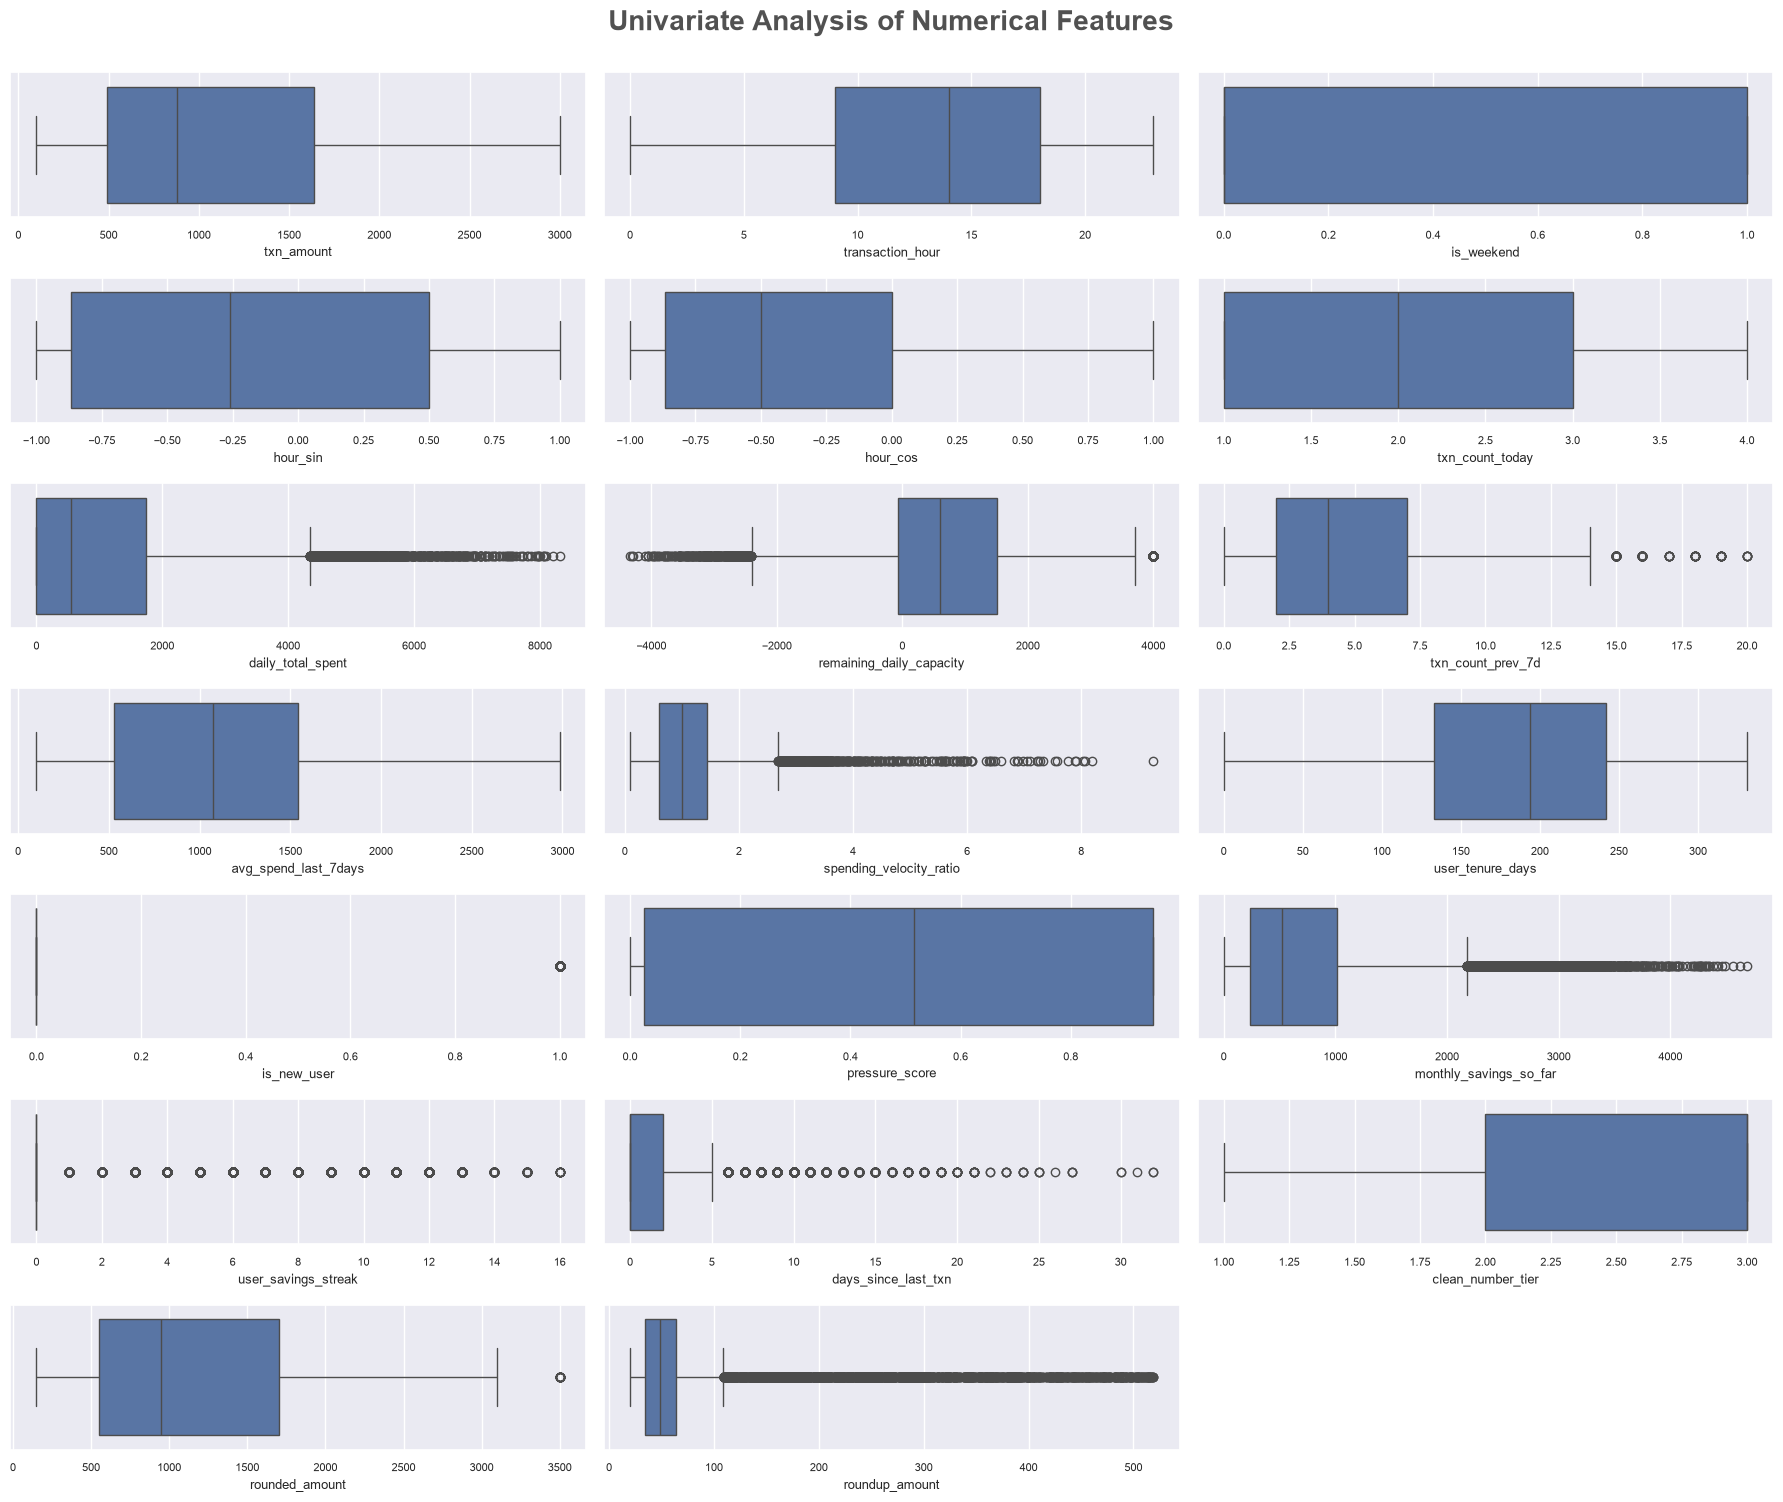

In [22]:
# outlier analysis - boxplot
plt.figure(figsize=(18,15))
plt.suptitle('Univariate Analysis of Numerical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(num_cols)):
    plt.subplot(7, 3, i+1)
    sns.boxplot(x=df[num_cols[i]],)
    plt.xlabel(num_cols[i])

plt.tight_layout()

# save plot
# plt.savefig('Univariate_Boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

### Key Takeaways — Numerical Features

- **Spending features** are heavily **right-skewed** → apply log transform, handle outliers  
- **Transaction counts** are low (mostly 1–4) → discrete/count behavior  
- **New users are rare** → strong class imbalance  
- **Pressure score is bimodal** → distinct low vs high segments  
- **Spending velocity** has extreme outliers → log/clip needed  
- **Remaining capacity** includes negatives → overspending signal  
- **Recency (days_since_last_txn)** is highly skewed → strong recent activity signal  
- **Round-up amount** is small & skewed → needs scaling/log transform  
- **Temporal features (hour_sin/cos)** are well-encoded → no change needed  
- **User tenure** is fairly smooth → minor scaling sufficient  
- **Clean number tier** is discrete → treat as categorical/ordinal

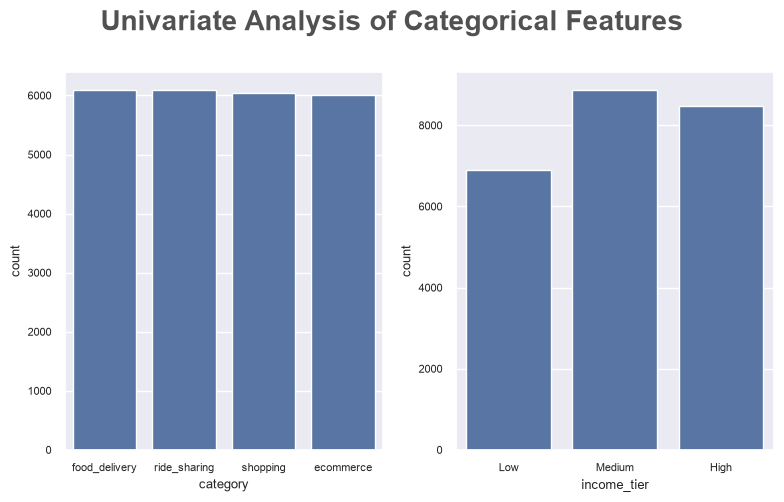

In [23]:
# categorical columns
cat_cols.remove('user_id')
cat_cols.remove('txn_id')
cat_cols.remove('timestamp')

plt.figure(figsize=(8, 5))
plt.suptitle('Univariate Analysis of Categorical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(cat_cols)):
    plt.subplot(1, 2, i+1)
    sns.countplot(x=df[cat_cols[i]])
    plt.xlabel(cat_cols[i])

plt.tight_layout()

# save plot
# plt.savefig('Univariate_Cat.png', dpi=300, bbox_inches='tight')
plt.show()

### Key Takeaways — Categorical Features

- **Transaction categories** are evenly distributed → no strong category dominance  
- **Income tiers** show moderate imbalance → more users in medium & high tiers  
- No severe skew → safe for standard encoding (one-hot or label)  
- Categories likely **weak standalone predictors** → better with interaction features  
- Consider combining with spending behavior for stronger signals  

---

### Bivariate Analysis — `roundup_amount` (target)

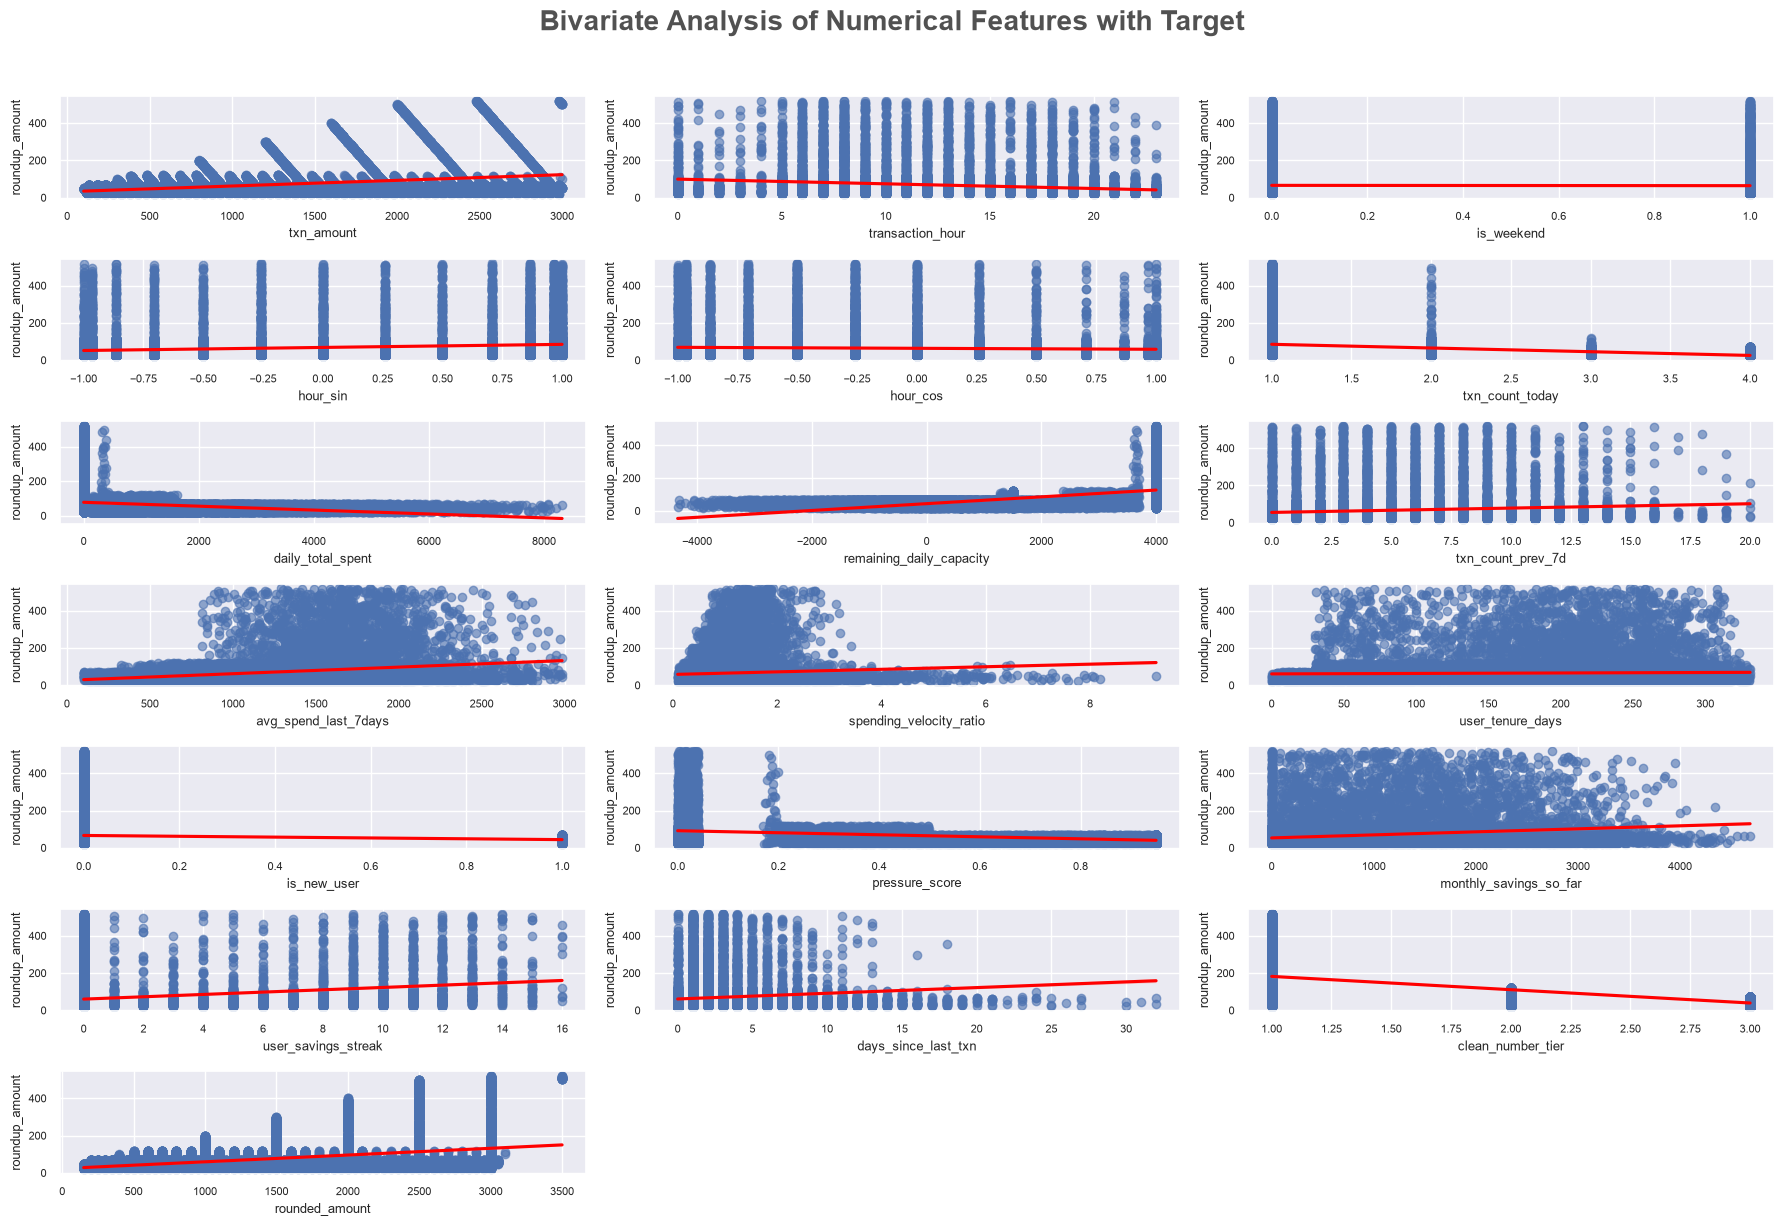

In [24]:
# Numerical Features
scatter_cols = [
      'txn_amount','transaction_hour', 'is_weekend', 'hour_sin', 'hour_cos',
      'txn_count_today', 'daily_total_spent', 'remaining_daily_capacity',
      'txn_count_prev_7d', 'avg_spend_last_7days', 'spending_velocity_ratio',
      'user_tenure_days', 'is_new_user', 'pressure_score',
      'monthly_savings_so_far', 'user_savings_streak', 'days_since_last_txn',
      'clean_number_tier', 'rounded_amount']

plt.figure(figsize=(18, 12))
plt.suptitle('Bivariate Analysis of Numerical Features with Target',
             fontsize=20, fontweight='bold', alpha=0.8, y=1.02)

for i, col in enumerate(scatter_cols):
    plt.subplot(7, 3, i+1)
    sns.regplot(x=df[col], y=df[TARGET_COL], scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
    plt.xlabel(col)
    plt.ylabel('roundup_amount')

plt.tight_layout()
# plt.savefig('Scatter_Num.png', dpi=300, bbox_inches='tight')
plt.show()

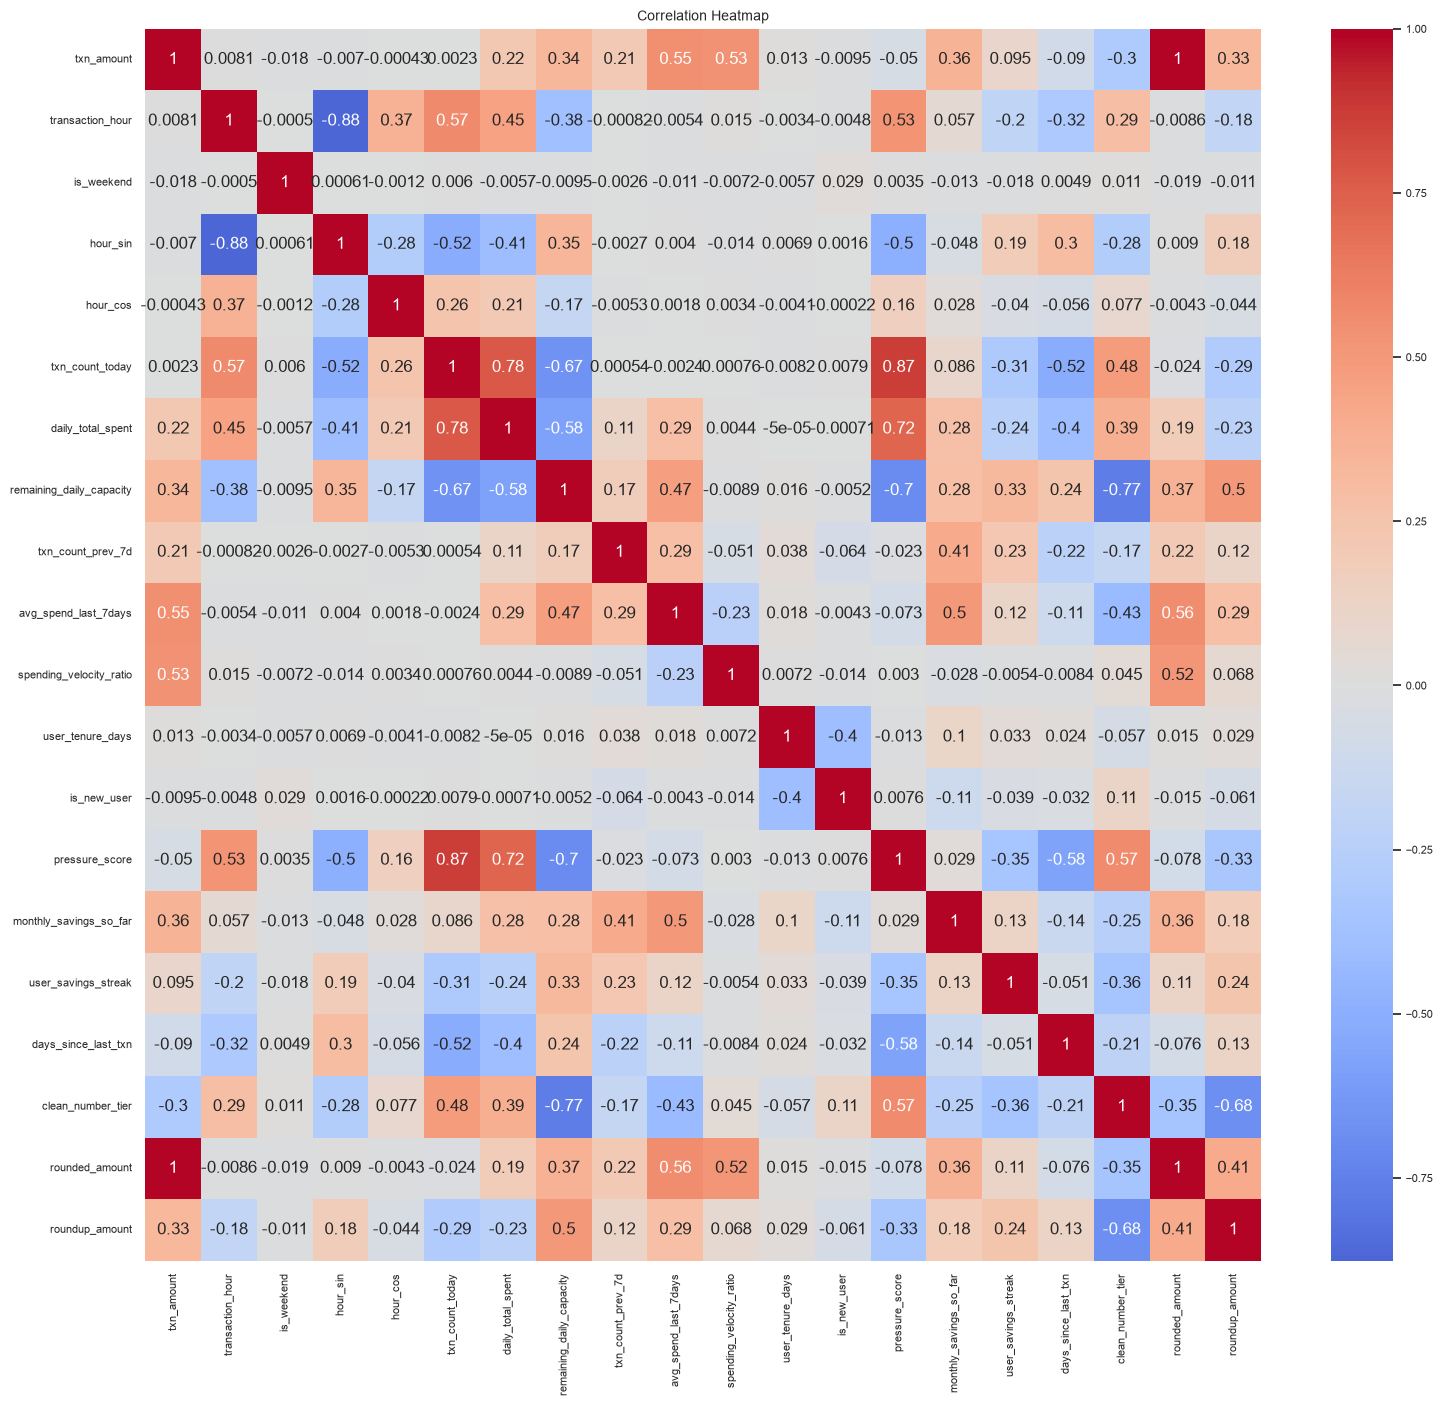

In [25]:
plt.figure(figsize=(18, 16))
sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

In [26]:
# Correlation with target column
corr_with_target = df[num_cols].corr()[TARGET_COL].sort_values(ascending=False)
print("\nCorrelation with Taget")
print(corr_with_target)


Correlation with Taget
roundup_amount              1.000
remaining_daily_capacity    0.504
rounded_amount              0.409
txn_amount                  0.331
avg_spend_last_7days        0.287
user_savings_streak         0.243
monthly_savings_so_far      0.180
hour_sin                    0.178
days_since_last_txn         0.125
txn_count_prev_7d           0.115
spending_velocity_ratio     0.068
user_tenure_days            0.029
is_weekend                 -0.011
hour_cos                   -0.044
is_new_user                -0.061
transaction_hour           -0.184
daily_total_spent          -0.231
txn_count_today            -0.290
pressure_score             -0.331
clean_number_tier          -0.682
Name: roundup_amount, dtype: float64


### Key Takeaways

- **Strongest positive drivers**: `remaining_daily_capacity`, `rounded_amount`, and `txn_amount` — higher values lead to higher round-up.
- **Moderate influence**: Spending behavior features like `avg_spend_last_7days` and `user_savings_streak` show positive trends.
- **Weak impact features**: `spending_velocity_ratio`, `user_tenure_days`, and `is_weekend` contribute little to prediction.
- **Negative drivers**: `pressure_score`, `txn_count_today`, and `daily_total_spent` reduce round-up amounts.
- **Strong negative signal**: `clean_number_tier` has the highest negative correlation, indicating structured rounding behavior.
- **Time-related features** (`transaction_hour`, `hour_sin/cos`) show minor or mixed effects.
- Overall, **financial capacity and recent spending behavior dominate the prediction**, while temporal and user profile features have limited impact.

---

### Feature Engineering & Model Training in Next ipynb